# Exploratory Data Analysis

Goal: understand household electricity consumption patterns before
feature engineering and forecasting.

Questions:
- What does the target distribution look like?
- How does consumption change over time?
- Are there hourly, daily, weekly, or monthly patterns?
- How are the electrical measurements related?
- Are there extreme values or unusual periods?

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = Path("../data/processed/household_power_validated.parquet")

df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(2075259, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 191.9 MB


In [4]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Sorted:", df["datetime"].is_monotonic_increasing)

Start: 2006-12-16 17:24:00
End: 2010-11-26 21:02:00
Sorted: True


## Global Active Power

In [5]:
df["Global_active_power"].describe()

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64

In [6]:
# check missing

target = df["Global_active_power"]

print("Missing:", target.isna().sum())
print("Missing %:", target.isna().mean() * 100)

Missing: 25979
Missing %: 1.2518437457686005


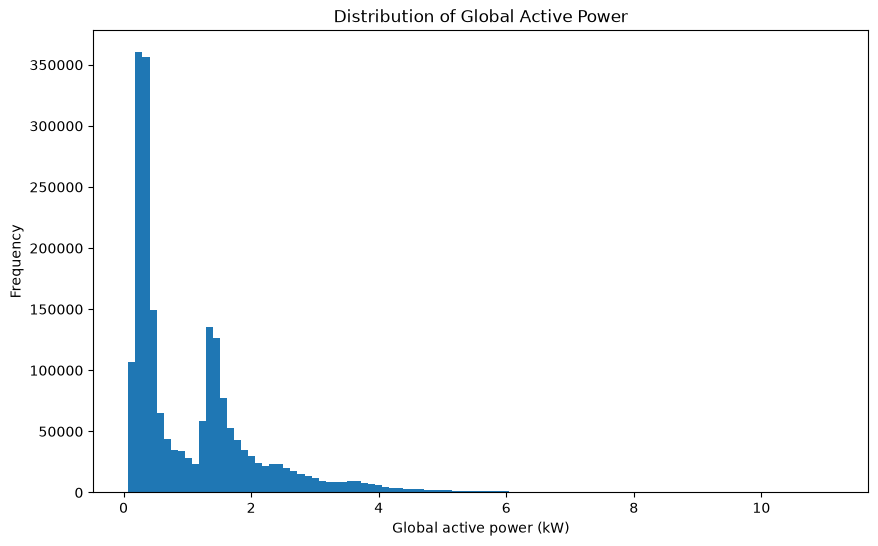

In [7]:
# plot distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df["Global_active_power"].dropna(),
    bins=100
)

plt.xlabel("Global active power (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")

plt.show()

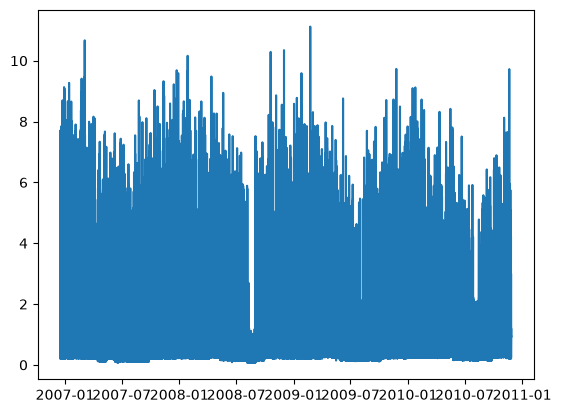

In [8]:
# time series

plt.plot(df["datetime"], df["Global_active_power"])

In [9]:
start = df["datetime"].min()
end = start + pd.Timedelta(days=7)

week = df[
    (df["datetime"] >= start)
    & (df["datetime"] < end)
]

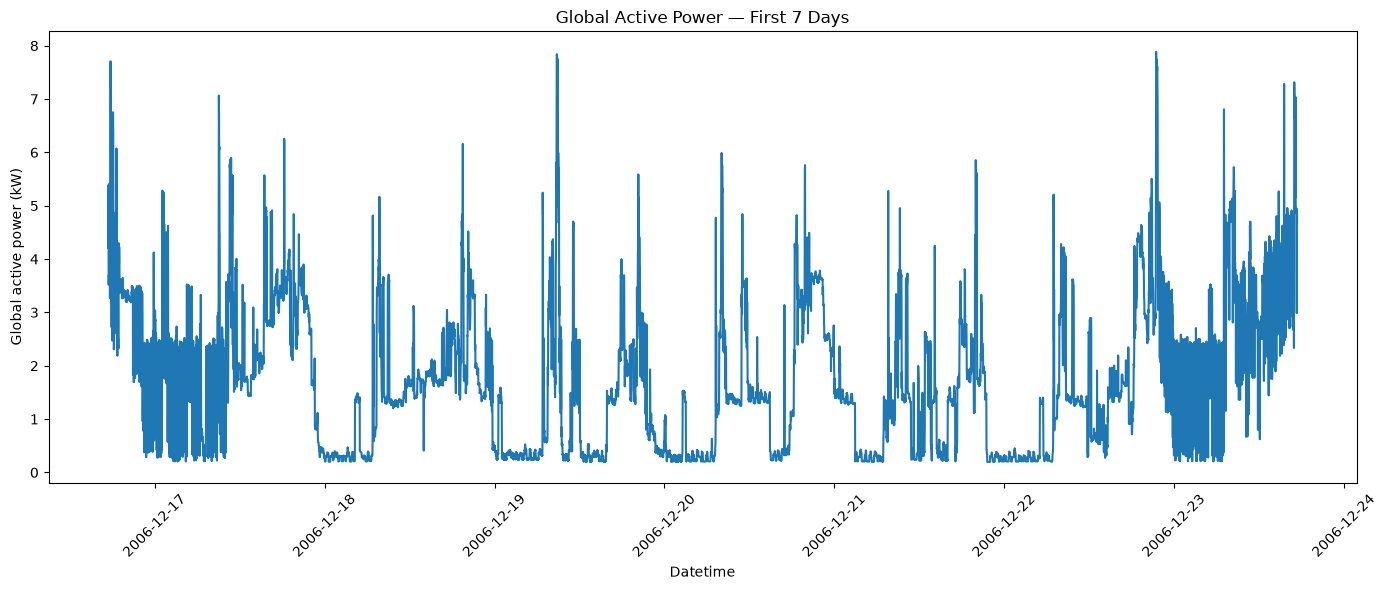

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    week["datetime"],
    week["Global_active_power"]
)

plt.xlabel("Datetime")
plt.ylabel("Global active power (kW)")
plt.title("Global Active Power — First 7 Days")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
# notice:
# baseline consumption
# spikes
# quiet overnight periods
# possible morning/evening peaks
# repeating daily behavior

In [12]:
# aggregate full dataset

daily_power = (
    df.set_index("datetime")["Global_active_power"]
    .resample("1D")
    .mean()
)


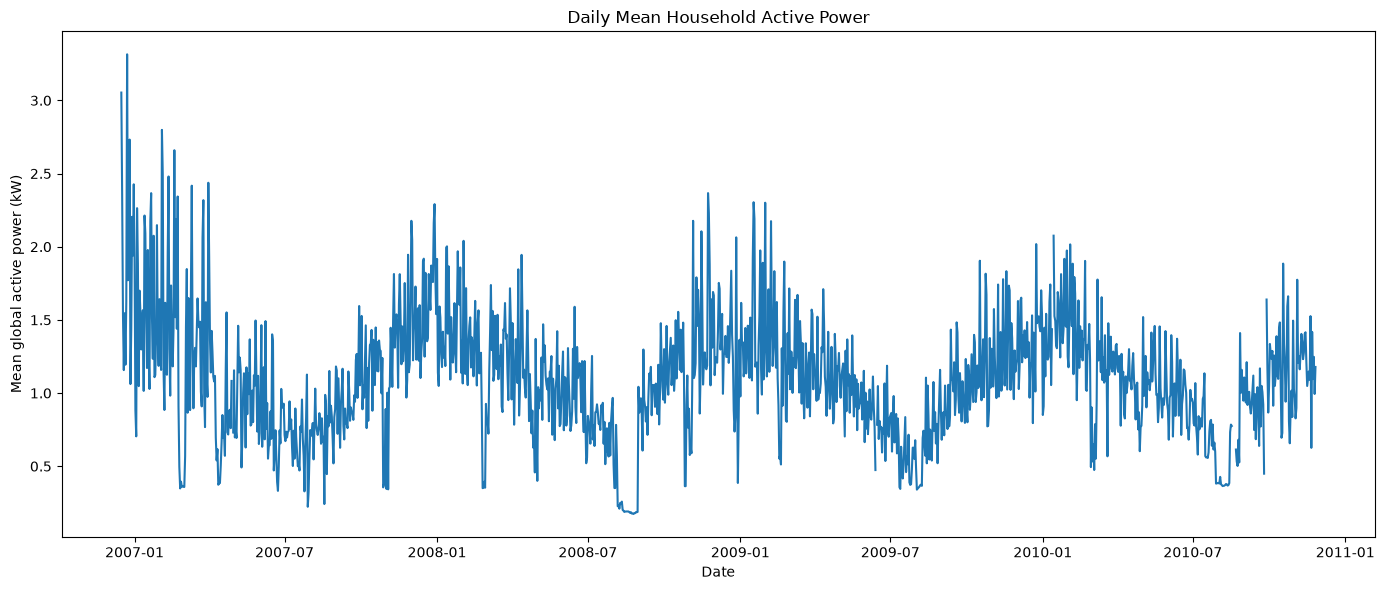

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_power.index,
    daily_power.values
)

plt.xlabel("Date")
plt.ylabel("Mean global active power (kW)")
plt.title("Daily Mean Household Active Power")

plt.tight_layout()
plt.show()

In [14]:
# looking for:

# seasonal changes
# long-term variation
# unusual periods
# the major missing-data gaps you found earlier

In [15]:
# hour of dat behavior

df["hour"] = df["datetime"].dt.hour

In [16]:
hourly_profile = (
    df.groupby("hour")["Global_active_power"]
    .mean()
)

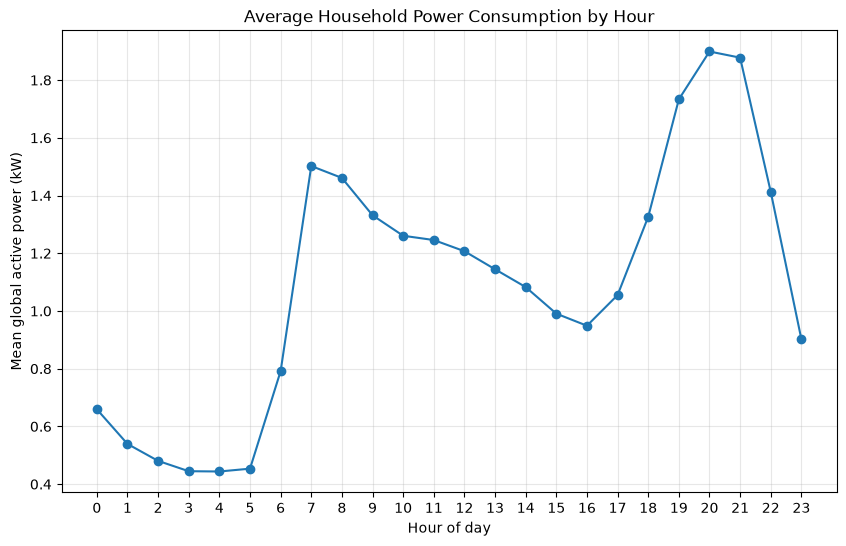

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Mean global active power (kW)")
plt.title("Average Household Power Consumption by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [18]:
# day of week behavior

df["day_of_week"] = df["datetime"].dt.dayofweek


In [19]:
# noteL
# monday = 0
# sunday = 6

In [20]:
weekday_profile = (
    df.groupby("day_of_week")["Global_active_power"]
    .mean()
)

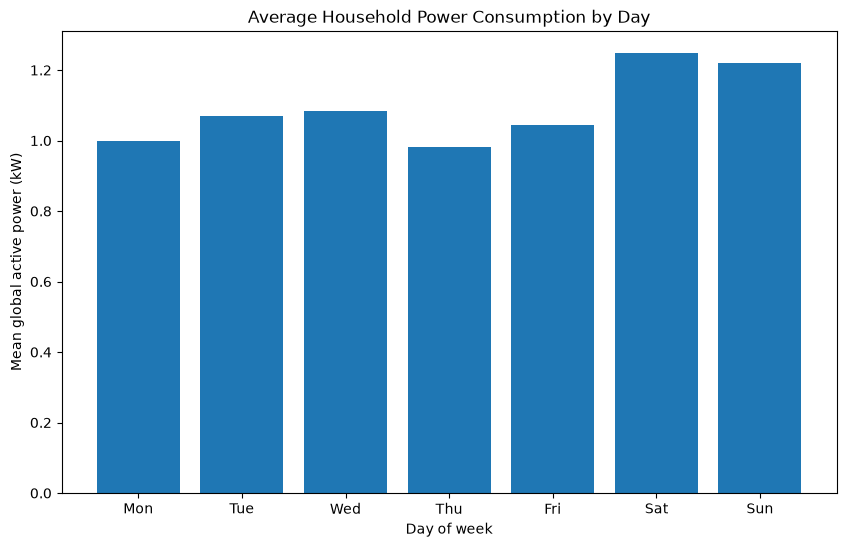

In [21]:
weekday_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_names,
    weekday_profile.values
)

plt.xlabel("Day of week")
plt.ylabel("Mean global active power (kW)")
plt.title("Average Household Power Consumption by Day")

plt.show()

In [22]:
# monthly patterns

df["month"] = df["datetime"].dt.month

monthly_profile = (
    df.groupby("month")["Global_active_power"]
    .mean()
)

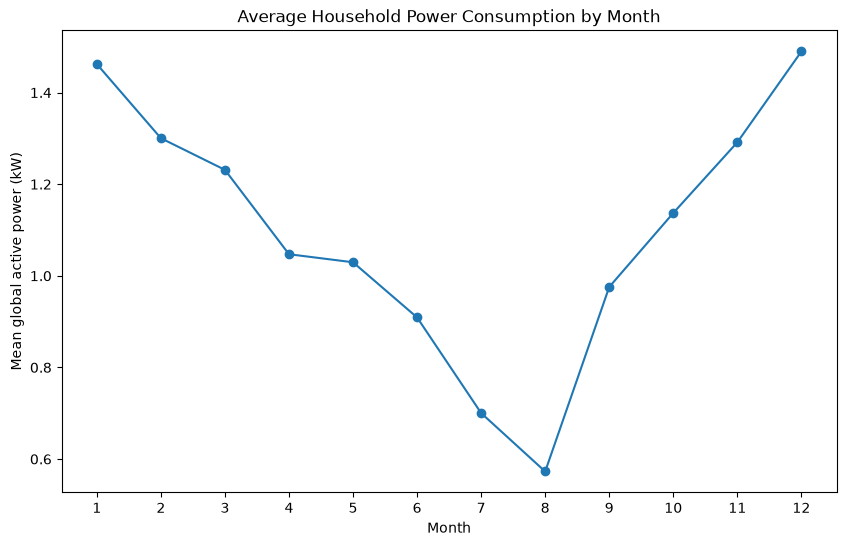

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Mean global active power (kW)")
plt.title("Average Household Power Consumption by Month")

plt.xticks(range(1, 13))

plt.show()

In [24]:
# goals for first eda pass:

# 1. Global_active_power.describe()
# 2. target histogram
# 3. first-week time-series plot
# 4. daily average over the full dataset
# 5. average consumption by hour
# 6. average consumption by weekday and month

## Relationships Among Electrical Measurements

In [25]:
electrical_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

corr = df[electrical_cols].corr()

corr.round(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000,0.247,-0.400,0.999,0.484,0.435,0.639
Global_reactive_power,0.247,1.000,-0.112,0.266,0.123,0.139,0.090
Voltage,-0.400,-0.112,1.000,-0.411,-0.196,-0.167,-0.268
Global_intensity,0.999,0.266,-0.411,1.000,0.489,0.440,0.627
Sub_metering_1,0.484,0.123,-0.196,0.489,1.000,0.055,0.103
Sub_metering_2,0.435,0.139,-0.167,0.440,0.055,1.000,0.081
Sub_metering_3,0.639,0.090,-0.268,0.627,0.103,0.081,1.000


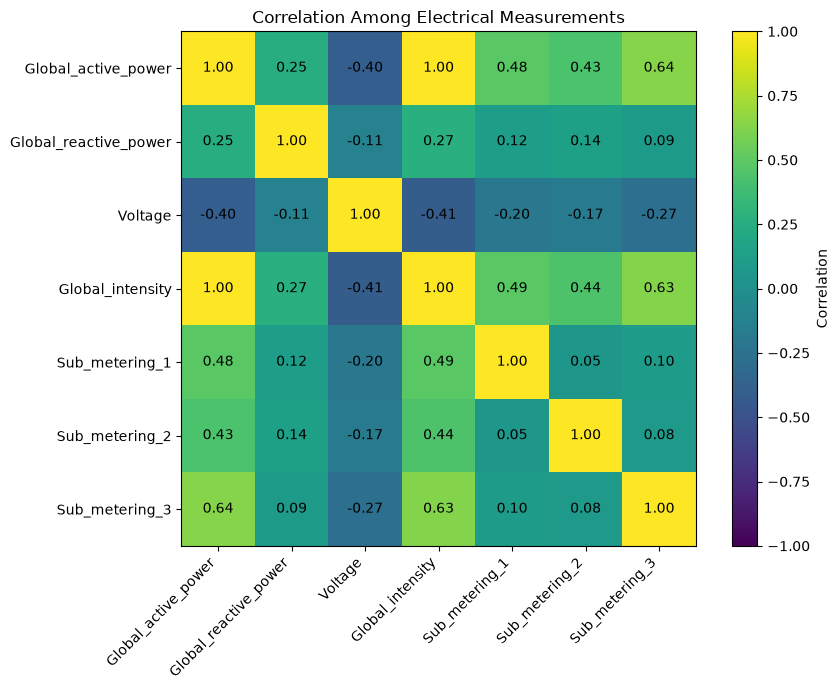

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(electrical_cols)))
ax.set_yticks(range(len(electrical_cols)))

ax.set_xticklabels(electrical_cols, rotation=45, ha="right")
ax.set_yticklabels(electrical_cols)

for i in range(len(electrical_cols)):
    for j in range(len(electrical_cols)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Correlation")

plt.title("Correlation Among Electrical Measurements")
plt.tight_layout()
plt.show()

In [27]:
sample = (
    df[electrical_cols]
    .dropna()
    .sample(
        n=20_000,
        random_state=42
    )
)

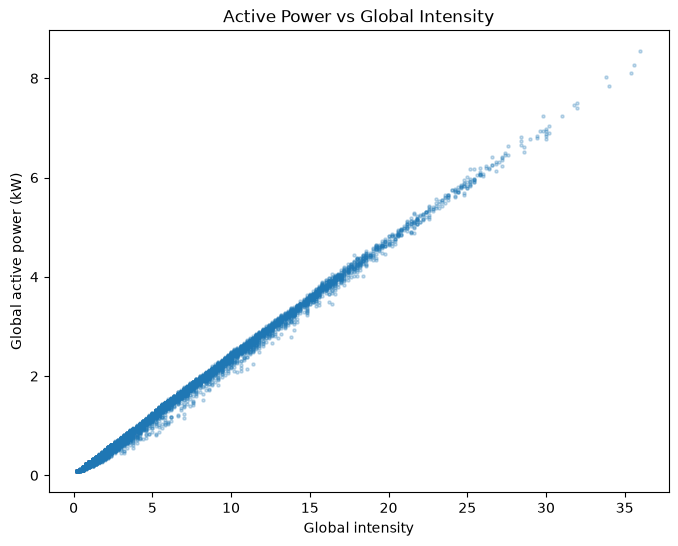

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sample["Global_intensity"],
    sample["Global_active_power"],
    s=5,
    alpha=0.25
)

plt.xlabel("Global intensity")
plt.ylabel("Global active power (kW)")
plt.title("Active Power vs Global Intensity")

plt.show()

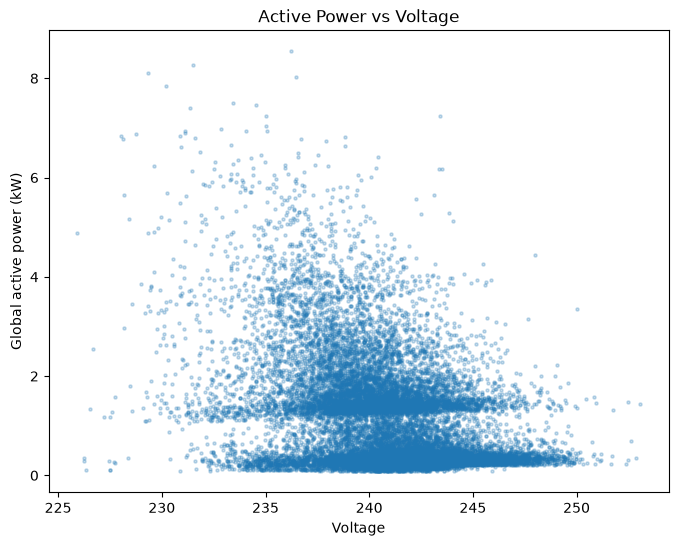

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sample["Voltage"],
    sample["Global_active_power"],
    s=5,
    alpha=0.25
)

plt.xlabel("Voltage")
plt.ylabel("Global active power (kW)")
plt.title("Active Power vs Voltage")

plt.show()

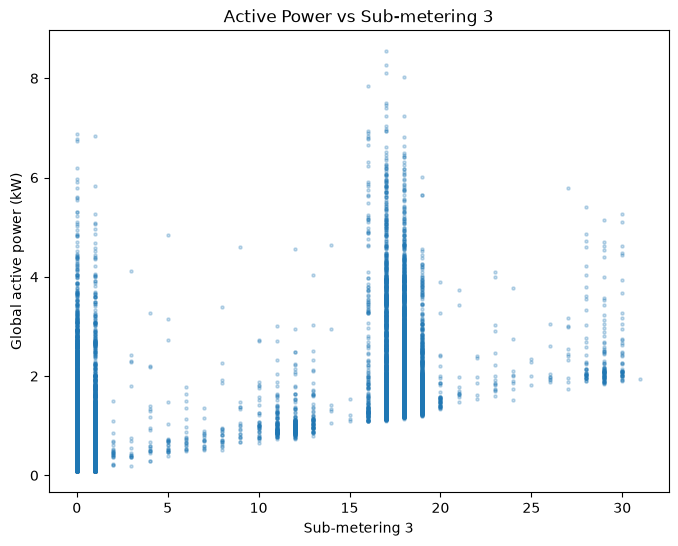

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sample["Sub_metering_3"],
    sample["Global_active_power"],
    s=5,
    alpha=0.25
)

plt.xlabel("Sub-metering 3")
plt.ylabel("Global active power (kW)")
plt.title("Active Power vs Sub-metering 3")

plt.show()